# Fase 4: Visualización y comunicación de resultados

## Introducción

En esta fase se presentan visualizaciones analíticas construidas a partir del dataset procesado y validado durante las fases anteriores. El objetivo es identificar tendencias, variaciones y patrones relevantes en los precios de los alimentos en Europa durante el período 2020–2025.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../../F2/data/processed/wfp_europe_2020_2025_clean.csv"
)

df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,archivo_origen,year,month
0,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),459,KG,actual,Retail,BYR,2.89,1.36,wfp_europe_2020_2025_clean.csv,2020,1
1,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,83,KG,actual,Retail,BYR,0.84,0.40,wfp_europe_2020_2025_clean.csv,2020,1
2,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Wheat flour,58,KG,actual,Retail,BYR,1.28,0.60,wfp_europe_2020_2025_clean.csv,2020,1
3,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),459,KG,actual,Retail,BYR,2.88,1.31,wfp_europe_2020_2025_clean.csv,2020,2
4,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,83,KG,actual,Retail,BYR,0.83,0.38,wfp_europe_2020_2025_clean.csv,2020,2


## Evolución del precio promedio anual

Se calcula el precio promedio anual considerando todos los productos y mercados disponibles en el dataset europeo.

In [2]:
promedio_anual = (
    df.groupby("year")["usdprice"]
      .mean()
      .reset_index()
)

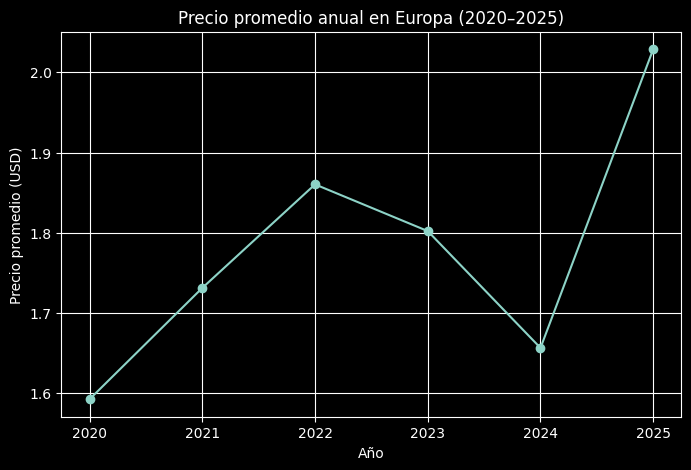

In [3]:
plt.figure(figsize=(8,5))

plt.plot(
    promedio_anual["year"],
    promedio_anual["usdprice"],
    marker="o"
)

plt.title("Precio promedio anual en Europa (2020–2025)")
plt.xlabel("Año")
plt.ylabel("Precio promedio (USD)")
plt.grid(True)

plt.savefig(
    "../results/grafico_precio_promedio.png",
    bbox_inches="tight"
)

plt.show()

## Interpretación

Durante el período 2020–2025 se observa una tendencia general al alza en el precio promedio de los alimentos registrados en el dataset europeo. Entre 2020 y 2022 el precio promedio aumentó desde aproximadamente 1,59 USD hasta 1,86 USD, lo que representa el mayor crecimiento sostenido del período analizado.

Posteriormente se observa una disminución moderada durante 2023 y 2024, seguida por un nuevo incremento significativo en 2025, alcanzando el valor promedio más alto de toda la serie (2,03 USD).

Si bien el aumento observado coincide temporalmente con el inicio del conflicto entre Rusia y Ucrania en 2022, los resultados deben interpretarse con cautela. Los precios de los alimentos están influenciados por múltiples factores económicos y geopolíticos, entre ellos las interrupciones en las cadenas de suministro, el aumento de los costos energéticos y de transporte, los procesos inflacionarios posteriores a la pandemia de COVID-19, las políticas monetarias adoptadas por distintos países y las variaciones en la oferta y demanda internacional de productos agrícolas.

Por lo tanto, los resultados sugieren una asociación temporal entre el período posterior a 2022 y el incremento de precios observado en el dataset, pero no permiten establecer una relación causal directa entre el conflicto y las variaciones registradas.

In [4]:
import sys
sys.path.append("../../F3/src")

from analizador import AnalizadorVariacionPrecios

In [5]:
analizador = AnalizadorVariacionPrecios(df)

df_variaciones = (
    analizador
    .calcular_variaciones_anuales()
)

excluir = [
    "Vasodilating agents (imported)",
    "Vasodilating agents (local)",
    "Antibiotics (local)",
    "Antibiotics (imported)"
]

top_aumentos = (
    df_variaciones
    .dropna()
    [~df_variaciones["commodity"].isin(excluir)]
    .sort_values(
        "variacion_pct",
        ascending=False
    )
    .head(10)
)

C:\Users\Bass\AppData\Local\Temp\ipykernel_15304\1500497242.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_variaciones


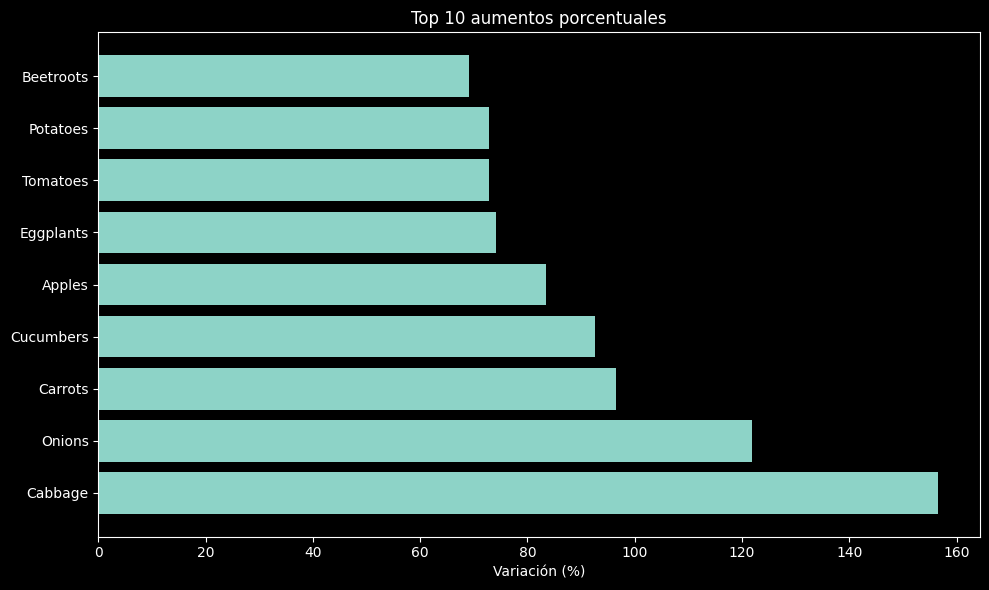

In [6]:
plt.figure(figsize=(10,6))

plt.barh(
    top_aumentos["commodity"],
    top_aumentos["variacion_pct"]
)

plt.title(
    "Top 10 aumentos porcentuales"
)

plt.xlabel(
    "Variación (%)"
)

plt.tight_layout()

plt.savefig(
    "../results/grafico_top_aumentos.png",
    bbox_inches="tight"
)

plt.show()

### Interpretación

Los resultados muestran que los mayores incrementos porcentuales observados entre 2020 y 2025 se concentraron principalmente en productos agrícolas frescos y de consumo habitual. Entre ellos destacan el repollo (Cabbage), con un aumento cercano al 156%, y la cebolla (Onions), con una variación superior al 120%.

También se registraron incrementos importantes en zanahorias, pepinos, manzanas, berenjenas, tomates y papas. En conjunto, estos resultados sugieren que los productos hortofrutícolas experimentaron una presión de precios superior al promedio general observado durante el período analizado.

Diversos factores pueden haber influido en este comportamiento, entre ellos el aumento de los costos energéticos, el encarecimiento del transporte, las fluctuaciones en los precios de fertilizantes, las alteraciones en las cadenas de suministro posteriores a la pandemia y diversos eventos climáticos que afectan la producción agrícola.

Aunque el conflicto entre Rusia y Ucrania constituye un elemento contextual relevante debido a la participación de ambos países en los mercados agrícolas internacionales, los resultados obtenidos no permiten establecer una relación causal directa. Más bien, evidencian que determinados productos agrícolas experimentaron incrementos de precio considerablemente superiores al promedio general registrado entre 2020 y 2025.

In [7]:
productos = [
    "Bread (high grade flour)",
    "Milk",
    "Onions"
]

df_productos = (
    df[df["commodity"].isin(productos)]
)

evolucion = (
    df_productos
    .groupby(
        ["year", "commodity"]
    )["usdprice"]
    .mean()
    .reset_index()
)

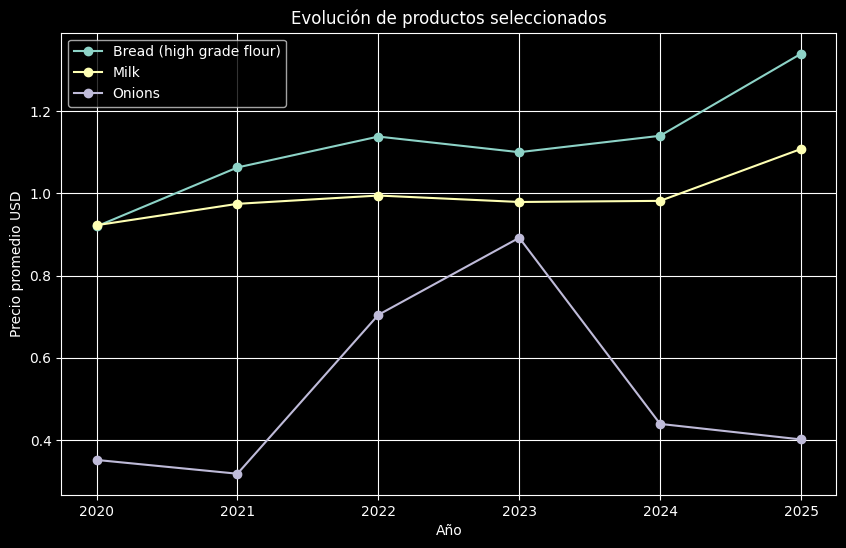

In [8]:
plt.figure(figsize=(10,6))

for producto in productos:

    datos = (
        evolucion[
            evolucion["commodity"]
            == producto
        ]
    )

    plt.plot(
        datos["year"],
        datos["usdprice"],
        marker="o",
        label=producto
    )

plt.title(
    "Evolución de productos seleccionados"
)

plt.xlabel("Año")
plt.ylabel("Precio promedio USD")

plt.legend()
plt.grid(True)

plt.savefig(
    "../results/grafico_productos_seleccionados.png",
    bbox_inches="tight"
)

plt.show()

## Interpretación

Los resultados muestran comportamientos distintos entre los productos seleccionados durante el período 2020–2025. El pan (Bread - high grade flour) presenta una tendencia general de crecimiento, pasando de aproximadamente 0,92 USD en 2020 a 1,34 USD en 2025. Aunque se observa una leve disminución en 2023, la tendencia global es claramente ascendente.

La leche (Milk) exhibe un comportamiento más estable, con incrementos moderados a lo largo del período. Su precio promedio aumenta desde aproximadamente 0,92 USD en 2020 hasta 1,11 USD en 2025, mostrando una menor volatilidad en comparación con los otros productos analizados.

Por su parte, la cebolla (Onions) presenta el comportamiento más variable. Entre 2021 y 2023 registra un aumento considerable, alcanzando un máximo cercano a 0,89 USD, pero posteriormente experimenta una disminución importante durante 2024 y 2025. Este patrón sugiere una mayor sensibilidad a cambios en las condiciones de oferta y demanda, así como a factores externos que afectan la producción agrícola.

En conjunto, los resultados evidencian que la evolución de los precios no fue homogénea entre todos los alimentos. Mientras algunos productos muestran incrementos sostenidos durante todo el período, otros presentan fluctuaciones significativas, lo que refuerza la idea de que múltiples factores económicos, logísticos y productivos influyen en la formación de precios dentro de los mercados alimentarios europeos.

# Conclusiones

Las visualizaciones desarrolladas permitieron identificar tendencias relevantes en la evolución de los precios de los alimentos en Europa durante el período 2020–2025. En términos generales, se observó una tendencia al alza en el precio promedio de los productos analizados, aunque con variaciones importantes entre distintas categorías alimentarias.

El análisis mostró que algunos productos agrícolas frescos, como el repollo y la cebolla, registraron incrementos porcentuales considerablemente superiores al promedio general. Asimismo, la evolución temporal de productos específicos evidenció comportamientos diferenciados, con algunos alimentos presentando aumentos sostenidos y otros mostrando fluctuaciones significativas entre años.

Los resultados sugieren que la evolución de los precios responde a una combinación de factores económicos, logísticos y productivos. Entre ellos pueden mencionarse las variaciones en los costos de energía, transporte y fertilizantes, las alteraciones en las cadenas de suministro internacionales, los efectos posteriores a la pandemia y el contexto geopolítico asociado al conflicto entre Rusia y Ucrania.

No obstante, el análisis realizado tiene un carácter exploratorio y descriptivo. Si bien se identifican asociaciones temporales entre determinados eventos y la evolución de los precios, los resultados no permiten establecer relaciones causales directas. En consecuencia, las visualizaciones constituyen una herramienta para comprender tendencias y patrones observados en los datos, proporcionando una base sólida para futuros análisis más específicos.

Finalmente, la integración de las fases del proyecto permitió construir un flujo reproducible que abarca la definición del problema, el preprocesamiento de datos, el análisis algorítmico y la comunicación visual de resultados, cumpliendo los objetivos planteados para el desarrollo del proyecto.